# **Importacao das biblitecas**

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet
import statsmodels.api as sm
from prophet.plot import plot_plotly, plot_components_plotly
from sklearn.metrics import mean_absolute_error, mean_squared_error
from  matplotlib.pylab import rcParams
rcParams['figure.figsize'] =15,7

In [8]:
# instaçacao prophet
!pip install prophet

In [58]:
#download airline-passengers

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df_raw = pd.read_csv(url)



In [59]:
df_raw.head(10)

,Month,Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121
5,1949-06,135
6,1949-07,148
7,1949-08,148
8,1949-09,136
9,1949-10,119


## Atençao  -  Passo fundamental Prophet exige as colunas **'ds' (data)** e **'y' (valor)**

In [61]:
df = df_raw.rename(columns={'Month': 'ds', 'Passengers': 'y'})
df['ds'] = pd.to_datetime(df['ds'])


In [37]:
df

,ds,y
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121
...,...,...
139,1960-08-01,606
140,1960-09-01,508
141,1960-10-01,461
142,1960-11-01,390


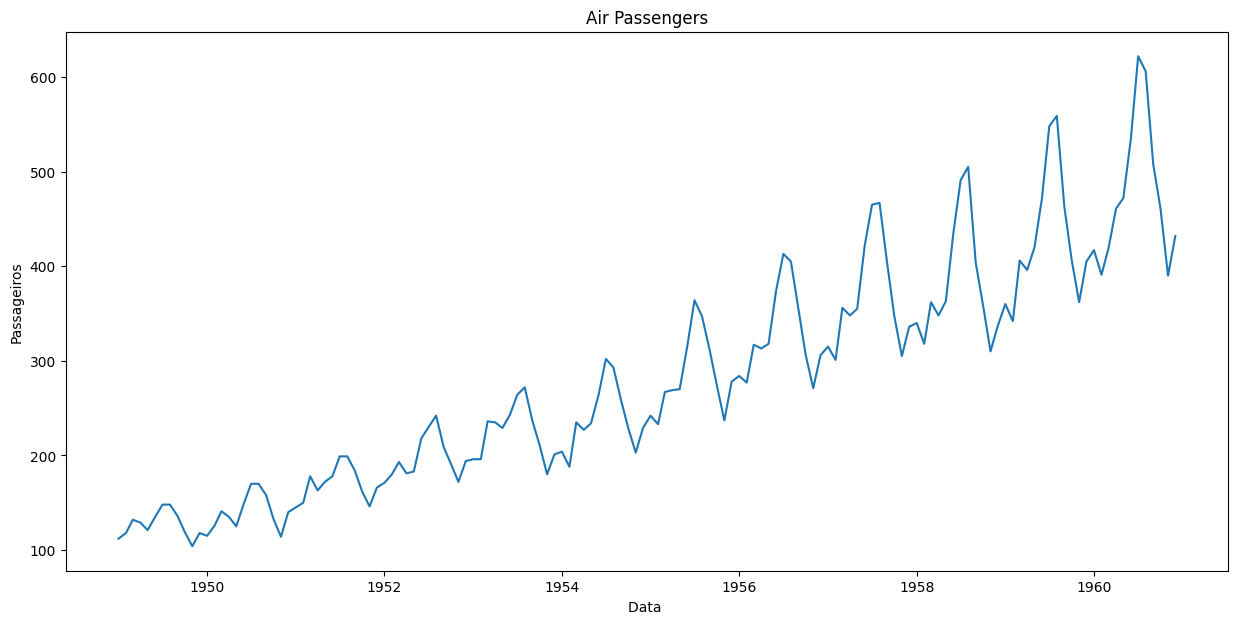

In [62]:
plt.plot(df['ds'], df['y'])
plt.title('Air Passengers')
plt.xlabel('Data ')
plt.ylabel('Passageiros')
plt.show()

In [63]:
n_teste = 24
dataset_treino = df.iloc[:-n_teste].copy()
dataset_teste  = df.iloc[-n_teste:].copy()

In [64]:
print(f"Dados de trinamento: {len(dataset_treino)} obs")
print(f"Dados de  Teste: {len(dataset_teste)} obs")

Dados de trinamento: 120 obs
Dados de  Teste: 24 obs


## **Definir o Modelo Prophet**

In [70]:
modelo_prophet = Prophet(
    growth="linear",              # tendência linear
    yearly_seasonality=True,      # sazonalidade anual
    weekly_seasonality=False,     # dados mensais → não faz sentido
    daily_seasonality=False,      # idem
    seasonality_mode="multiplicative",  # variância cresce → multiplicativo
    changepoint_prior_scale=0.5,  # flexibilidade da tendência
    seasonality_prior_scale=10.0, # força da sazonalidade
    interval_width=0.95           # IC de 95%
)

## **Ajustar o modelo**

In [71]:
modelo_prophet.fit(dataset_treino)

## **make_future_dataframe()**
O método **make_future_dataframe()** pertence à biblioteca Prophet e é responsável por gerar automaticamente um novo DataFrame contendo o histórico de datas passado acrescido das datas futuras para as quais você deseja realizar as previsões.

## **Parâmetros**

*  **periods = n_teste :** Define a quantidade exata de passos (períodos) no futuro que o modelo deve projetar após a última data presente no conjunto de dados original.

* **freq = "MS":**  Especifica a frequência (o intervalo temporal) entre cada uma das novas datas geradas no futuro. Frequências Comuns no Pandas/Prophet:

  * **"MS"**: Mensal (no início do mês)
  * **"M"**: Mensal (no último dia do mês)
  *  **"D"**: Diária
  *  **"W"**: Semanal
  *  **"Y" / "YS"**: Anual

In [72]:
futuro = modelo_prophet.make_future_dataframe(periods=n_teste, freq="MS")

In [73]:
previsao_modelo_prophet = modelo_prophet.predict(futuro)

In [74]:
# Colunas principais
print(previsao_modelo_prophet[["ds", "yhat", "yhat_lower", "yhat_upper"]])

            ds        yhat  yhat_lower  yhat_upper
0   1949-01-01  115.271490  100.796709  130.070562
1   1949-02-01  109.206618   94.890911  123.514017
2   1949-03-01  127.882402  113.686320  143.223814
3   1949-04-01  122.845474  107.367512  137.610407
4   1949-05-01  122.835155  108.024528  136.656870
..         ...         ...         ...         ...
139 1960-08-01  535.432282  467.567468  602.911711
140 1960-09-01  461.525135  402.033370  526.113504
141 1960-10-01  401.973135  346.463556  457.317162
142 1960-11-01  354.839025  301.284047  407.283309
143 1960-12-01  392.369408  331.585709  455.477055

[144 rows x 4 columns]


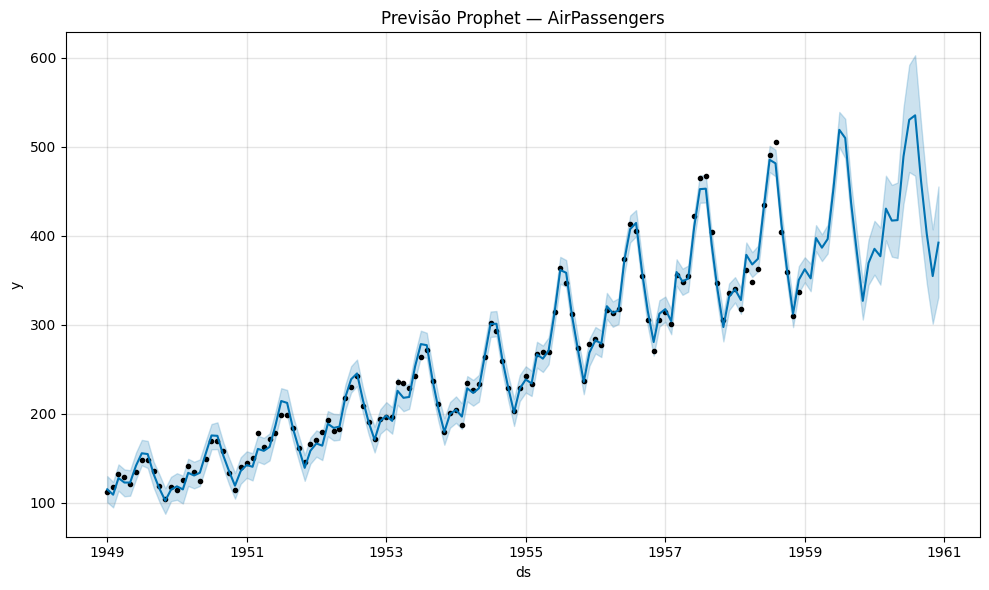

In [75]:
fig1 = modelo_prophet.plot(previsao_modelo_prophet)
plt.title("Previsão Prophet — AirPassengers")
plt.tight_layout()
plt.show()

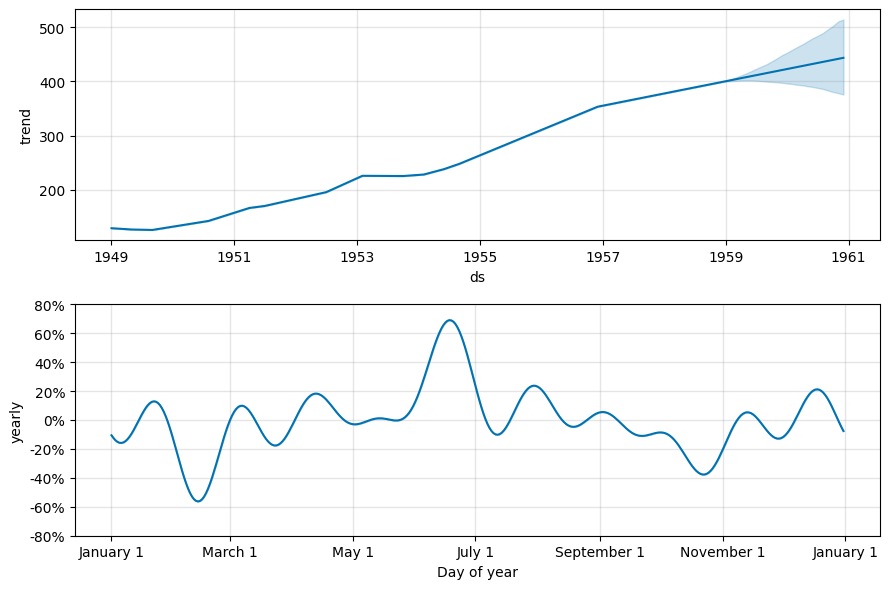

In [76]:
# Componentes: tendência + sazonalidade anual
fig2 = modelo_prophet.plot_components(previsao_modelo_prophet)
plt.tight_layout()
plt.show()

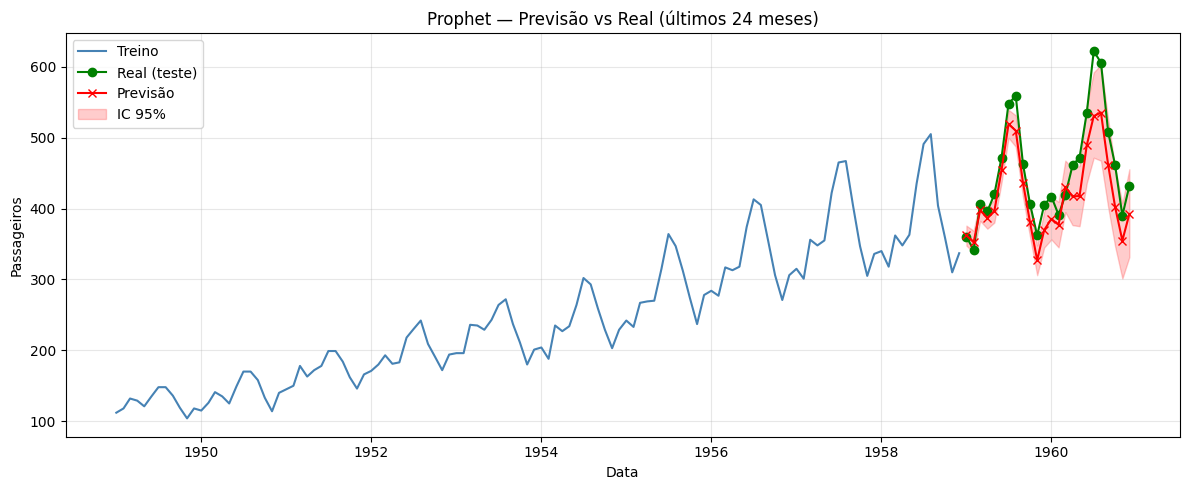

In [77]:
prev_teste = previsao_modelo_prophet.set_index("ds").loc[dataset_teste["ds"]]

plt.figure(figsize=(12, 5))
plt.plot(dataset_treino["ds"],dataset_treino["y"], label="Treino", color="steelblue")
plt.plot(dataset_teste["ds"], dataset_teste["y"], label="Real (teste)", color="green", marker="o")
plt.plot(prev_teste.index, prev_teste["yhat"], label="Previsão", color="red", marker="x")
plt.fill_between(
    prev_teste.index,
    prev_teste["yhat_lower"],
    prev_teste["yhat_upper"],
    color="red", alpha=0.2, label="IC 95%"
)
plt.title("Prophet — Previsão vs Real (últimos 24 meses)")
plt.xlabel("Data")
plt.ylabel("Passageiros")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()